In [1]:
%matplotlib notebook
from islpy import *
from tools import plot_3d_set, plot_3d_sets
from tools import split_affine, split_vertices

# 3D reduction with 1D accumulation & 2D reuse

We have the following base cases and general cases.

Assume that the accumulation and reuse space are along the canonic axes where:  
\- acummulation upwards along $\hat{k}$  
\- reuse horizontally in the $ij$-plane (meaning ANY face in the $ij$-plane will ALWAYS be invariant regardless of the choice of $\rho$

Any "horizontal" cut (parallel to the $ij$-plane) will expose new strong invariant faces.
And any vertical cut (containing $\hat{k}$ as a basis will expose new strong boundary faces.

Note that there can only every be one strong invariant face, but there may be up to two strong boundary faces.

The process of identifying "covered" edges involves projecting the tetrahedra onto the larger of the reuse and accumulation space, or projecting out the smaller.
In this case, it means projecting onto the reuse space (i.e., onto the $ij$-plane) or to project out the accumulation space (i.e., project out $k$ component).

## base case: 2 or fewer oblique faces

When there are only 2 or fewer oblique faces we do the following to exploit 1 dimension of reuse.

If there is only 1 oblique face, then the space of feasible reuse is non-empty:
1. select any $\rho$ and if it labels the oblique face as a $\ominus$-face then negate it.

If there are 2 oblique faces, then do the following:
1. pick an oblique face and intersect it with the $ij$-plane -- they intersect in a line.
2. select a $\rho$ in this intersection -- this $\rho$ labels the oblique face as an $\varnothing$-face.
2. if $\rho$ labels the other oblique face as $\ominus$ then negate it

<IPython.core.display.Javascript object>


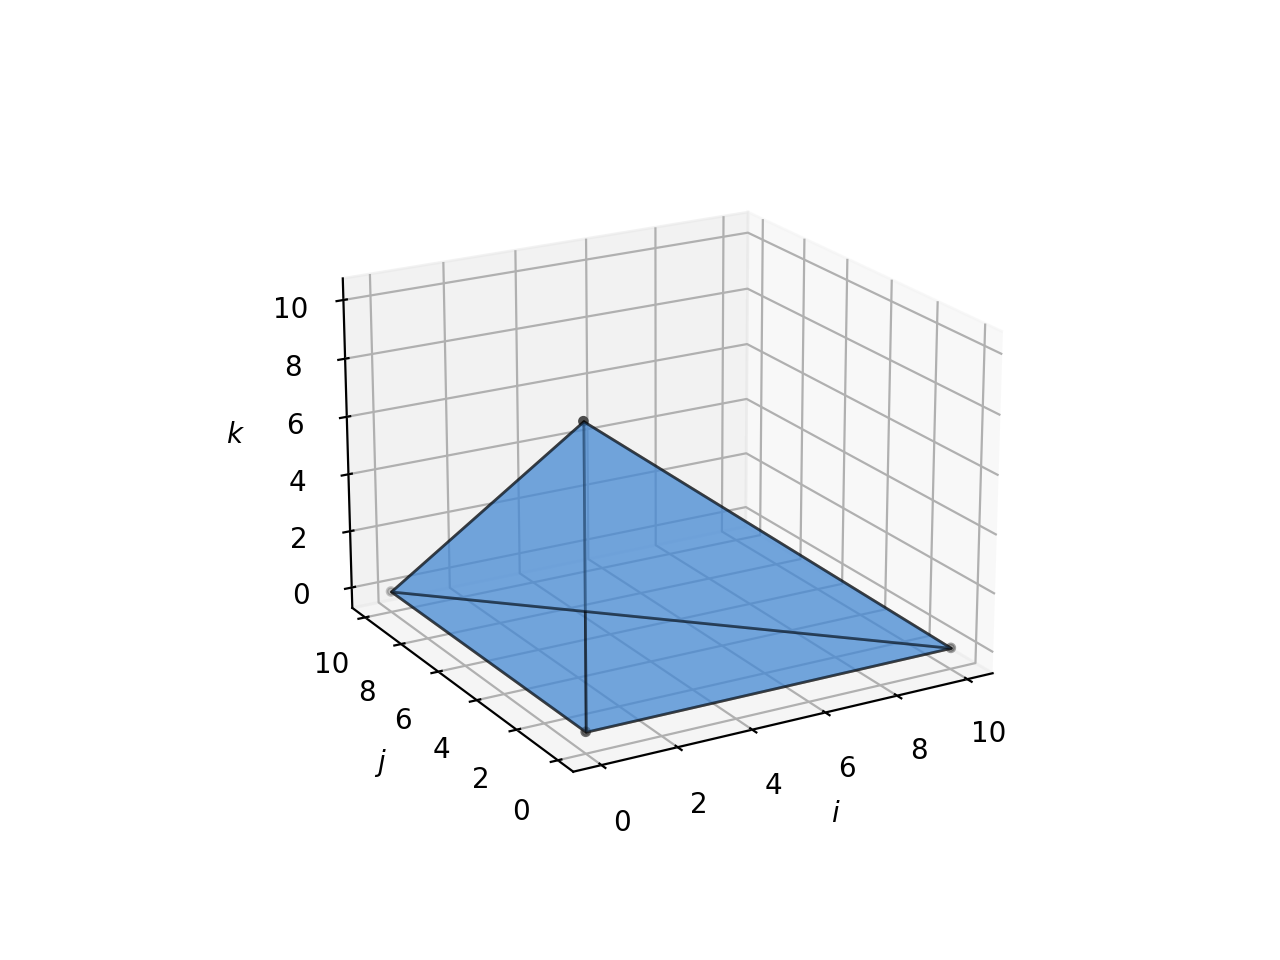

In [2]:
# 1 strong invariant face
# 2 strong boundary faces
# 1 oblique face
s = Set('{[10,0,0]; [0,10,0]; [0,0,10]; [0,0,0];}').convex_hull()
plot_3d_set(s)

<IPython.core.display.Javascript object>


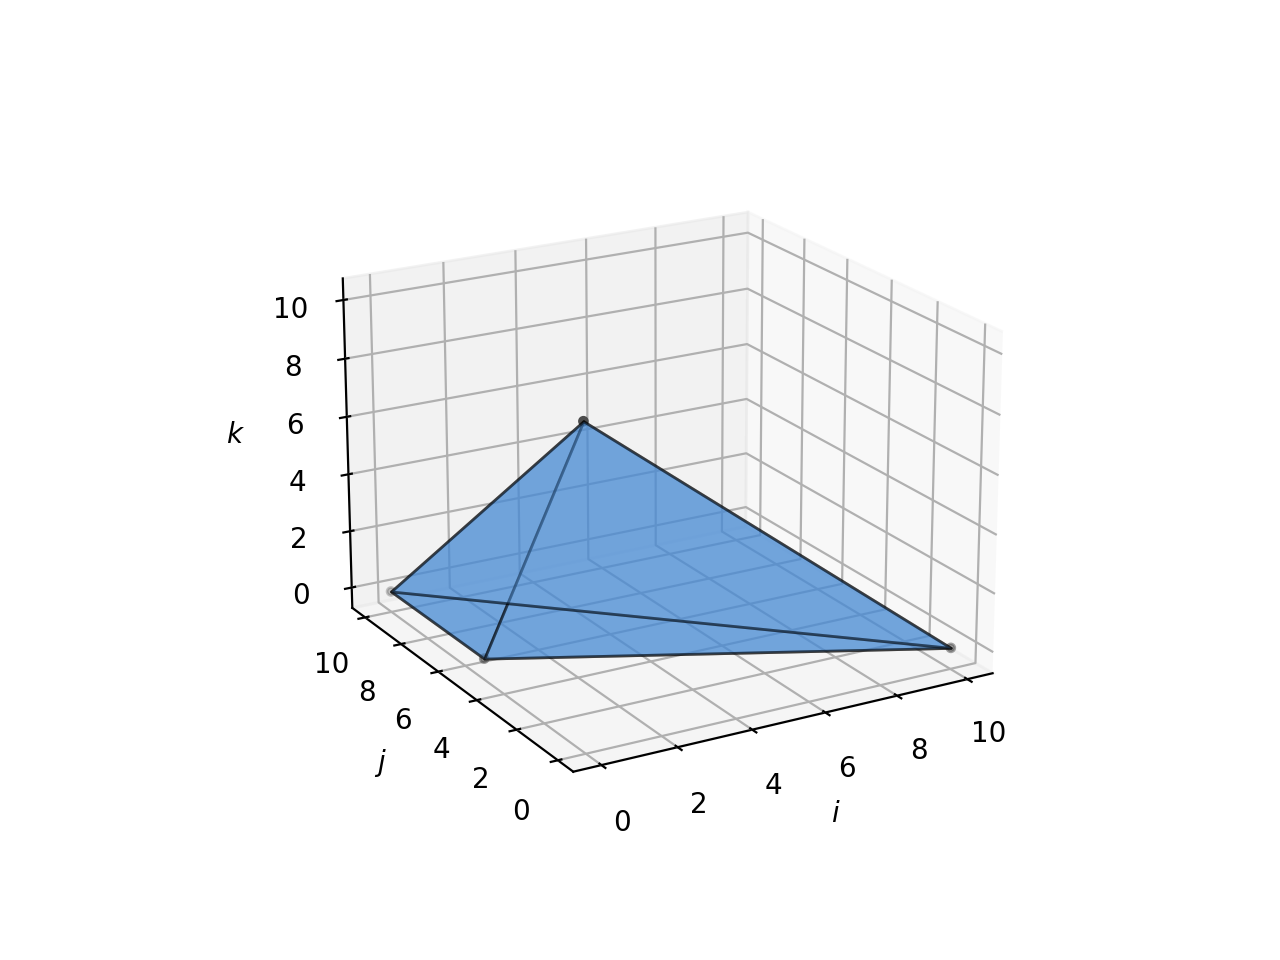

In [3]:
# 1 strong invariant face
# 1 strong boundary face
# 2 oblique faces
s = Set('{[0,5,0]; [10,0,0]; [0,10,0]; [0,0,10];}').convex_hull()
plot_3d_set(s)

<IPython.core.display.Javascript object>


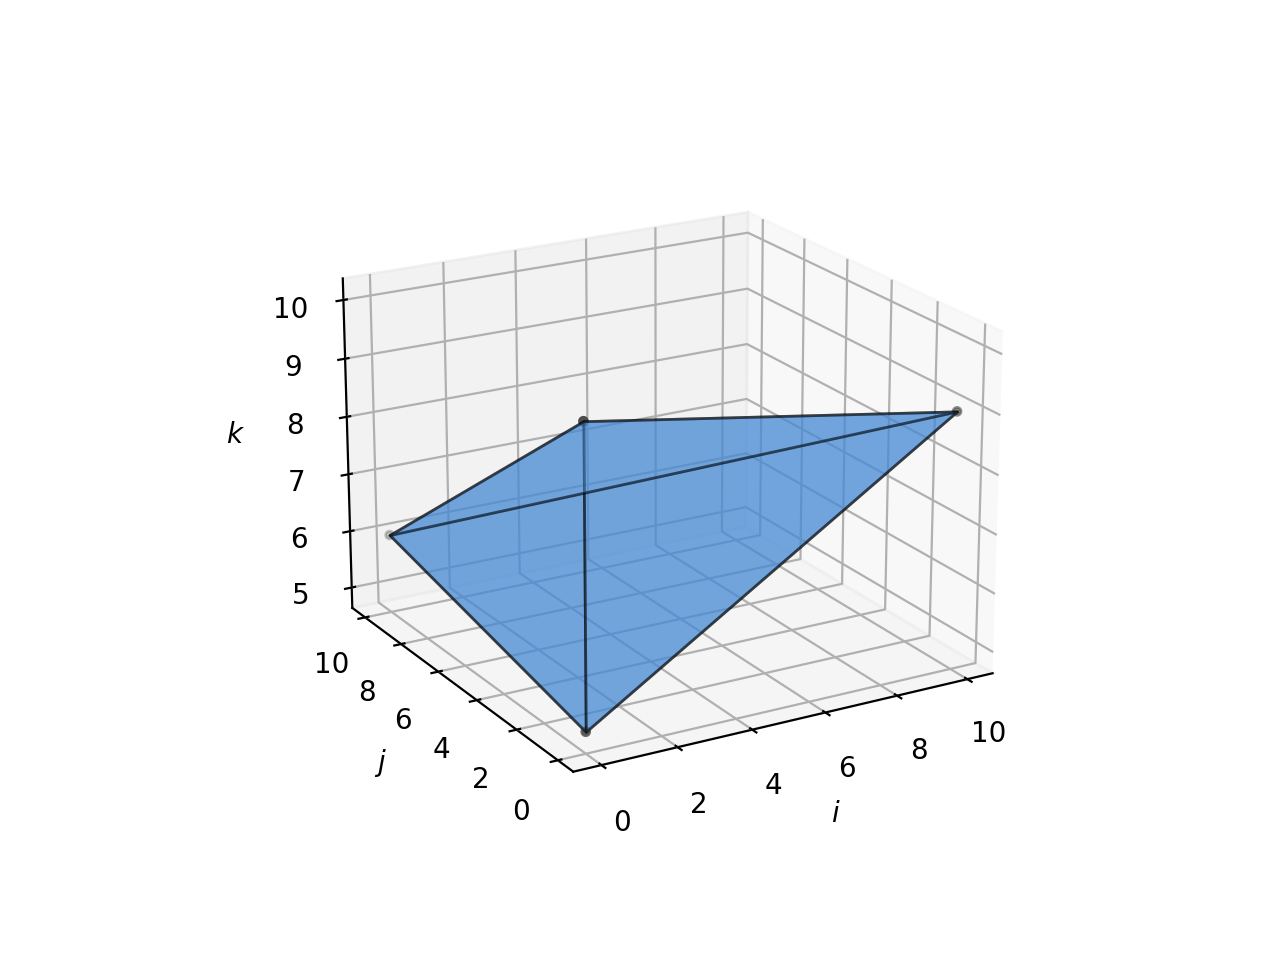

In [4]:
# 0 strong invariant faces
# 2 strong boundary faces
# 2 oblique faces
s = Set('{[0,0,5]; [10,0,9]; [0,10,6]; [0,0,10];}').convex_hull()
plot_3d_set(s)

## Scenario 1) 1 strong invariant face, 3 oblique faces

## Scenario 1a) top vertex interior

<IPython.core.display.Javascript object>


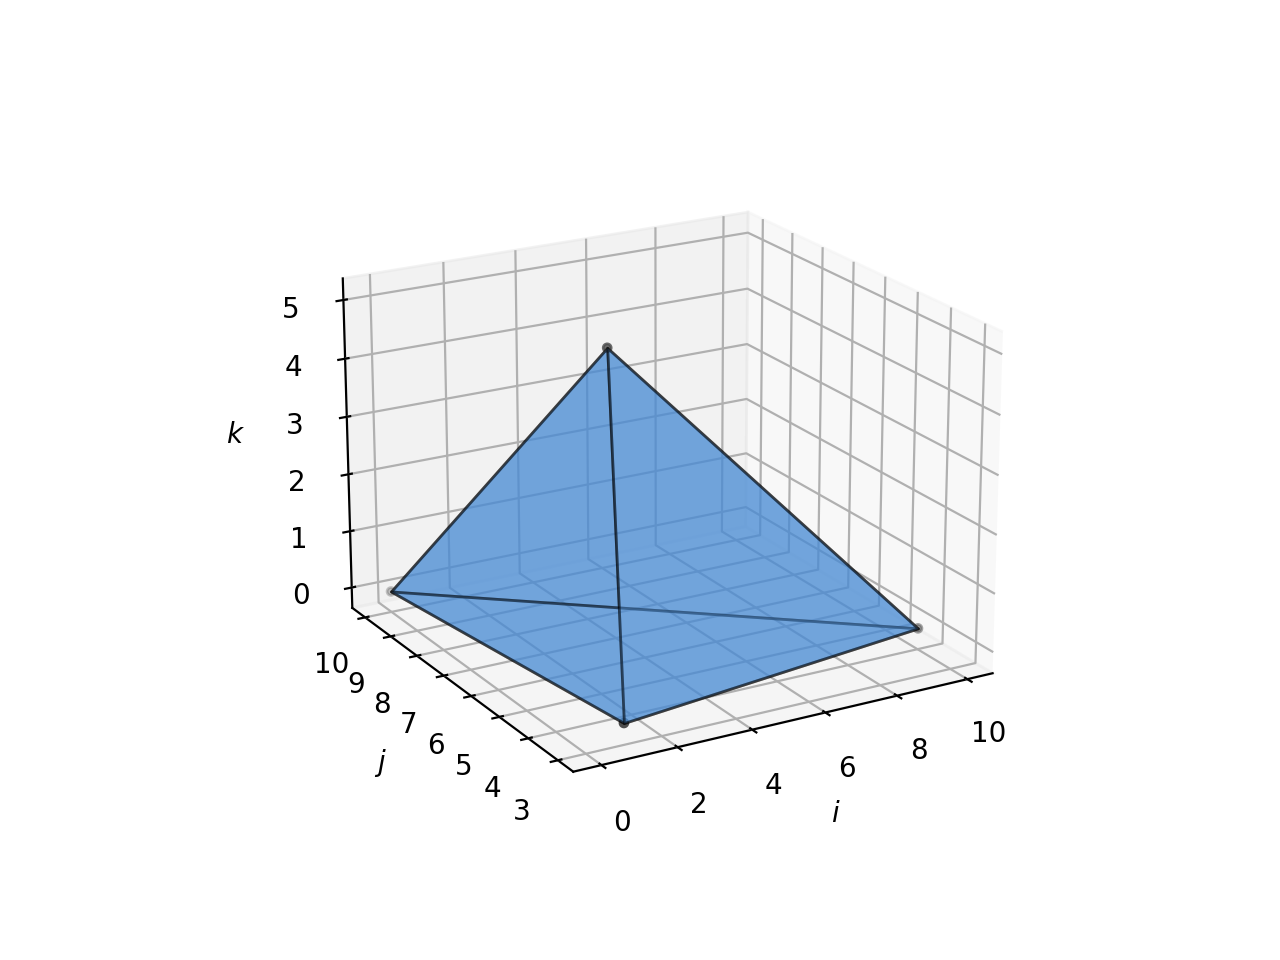

In [5]:
# 1 strong invariant face
# 0 strong boundary faces
# 3 oblique faces
# subcase - top vertex interior
s = Set('{[1,3,0]; [10,4,0]; [0,10,0]; [3,6,5];}').convex_hull()
plot_3d_set(s)

### resolution - single boundary cut through any top edge produces 2 tetrahedra in the base case

<IPython.core.display.Javascript object>


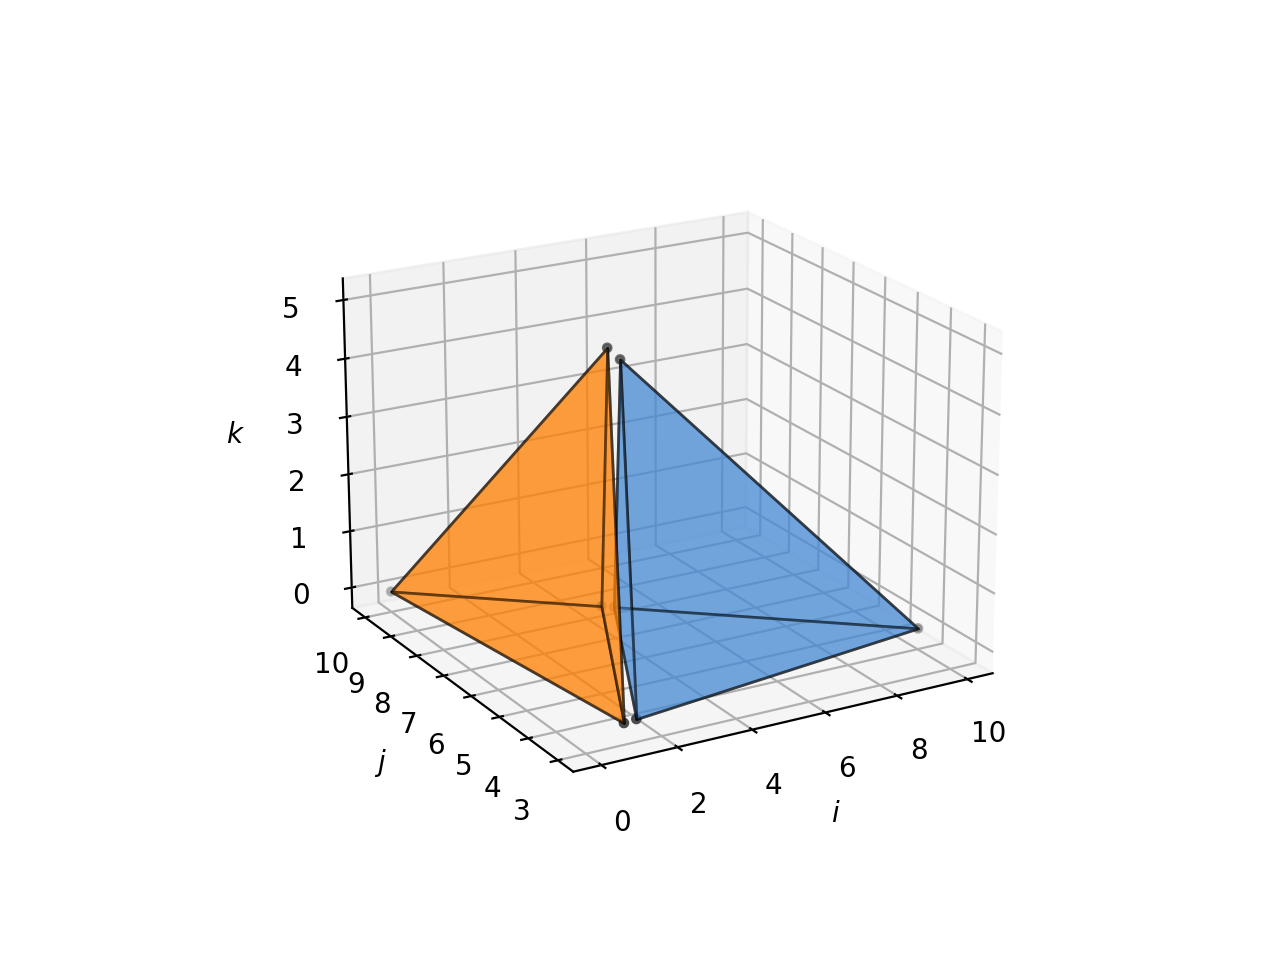

In [6]:
# subcase - top vertex interior
s = Set('{[1,3,0]; [10,4,0]; [0,10,0]; [3,6,5];}').convex_hull()

# resolution
pieces = split_affine(s, "3i=2j-2")

plot_3d_sets(pieces)

## Scenario 1b) top vertex exterior

<IPython.core.display.Javascript object>


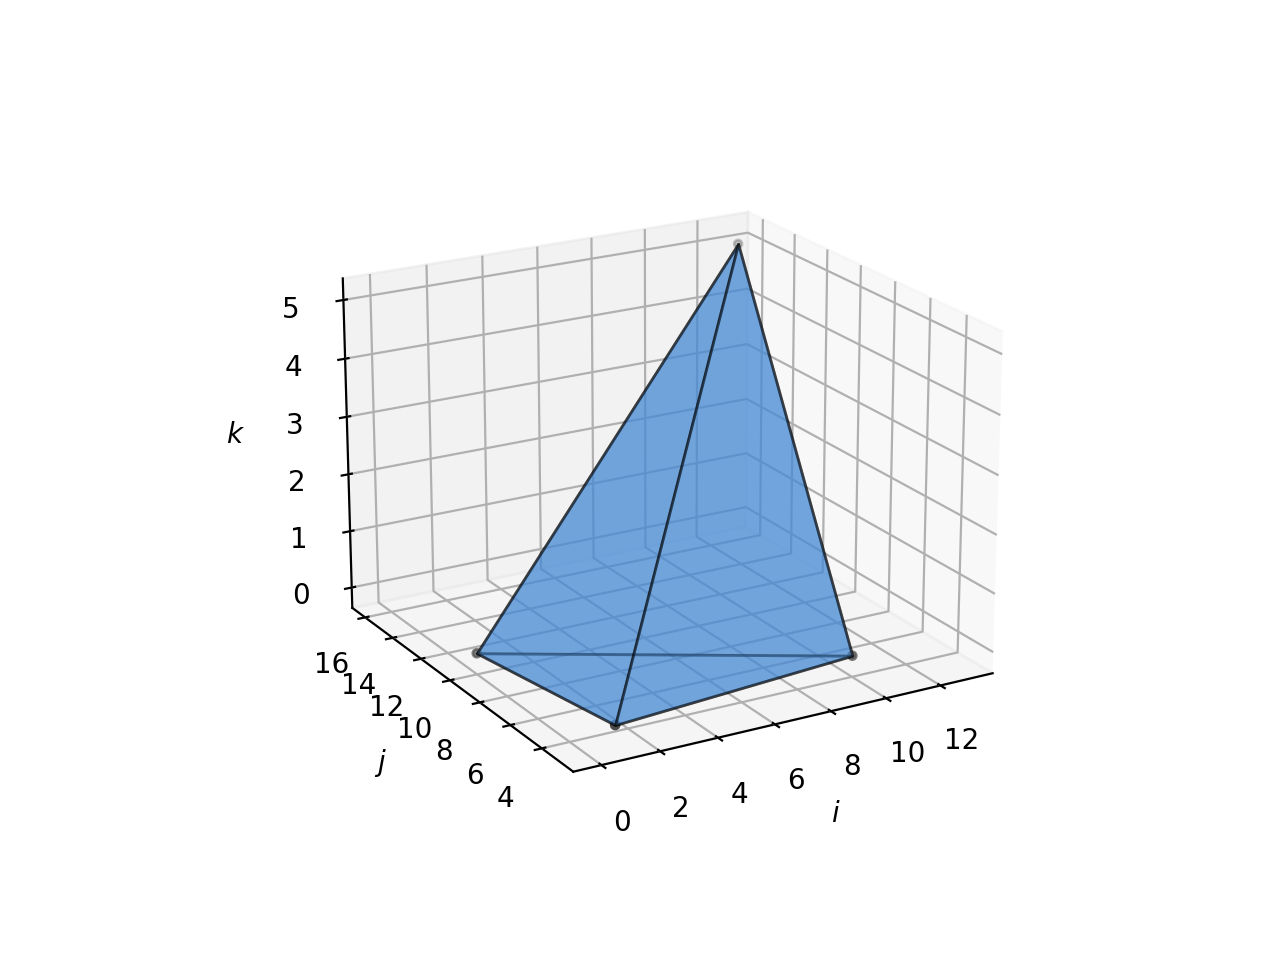

In [7]:
# 1 strong invariant face
# 0 strong boundary faces
# 3 oblique faces
# subcase - top vertex exterior
s = Set('{[1,3,0]; [10,4,0]; [0,10,0]; [13,16,5];}').convex_hull()
plot_3d_set(s)

### resolution - boundary cut through covered edge gives one tetrahedron in base case & one in scenario 2

<IPython.core.display.Javascript object>


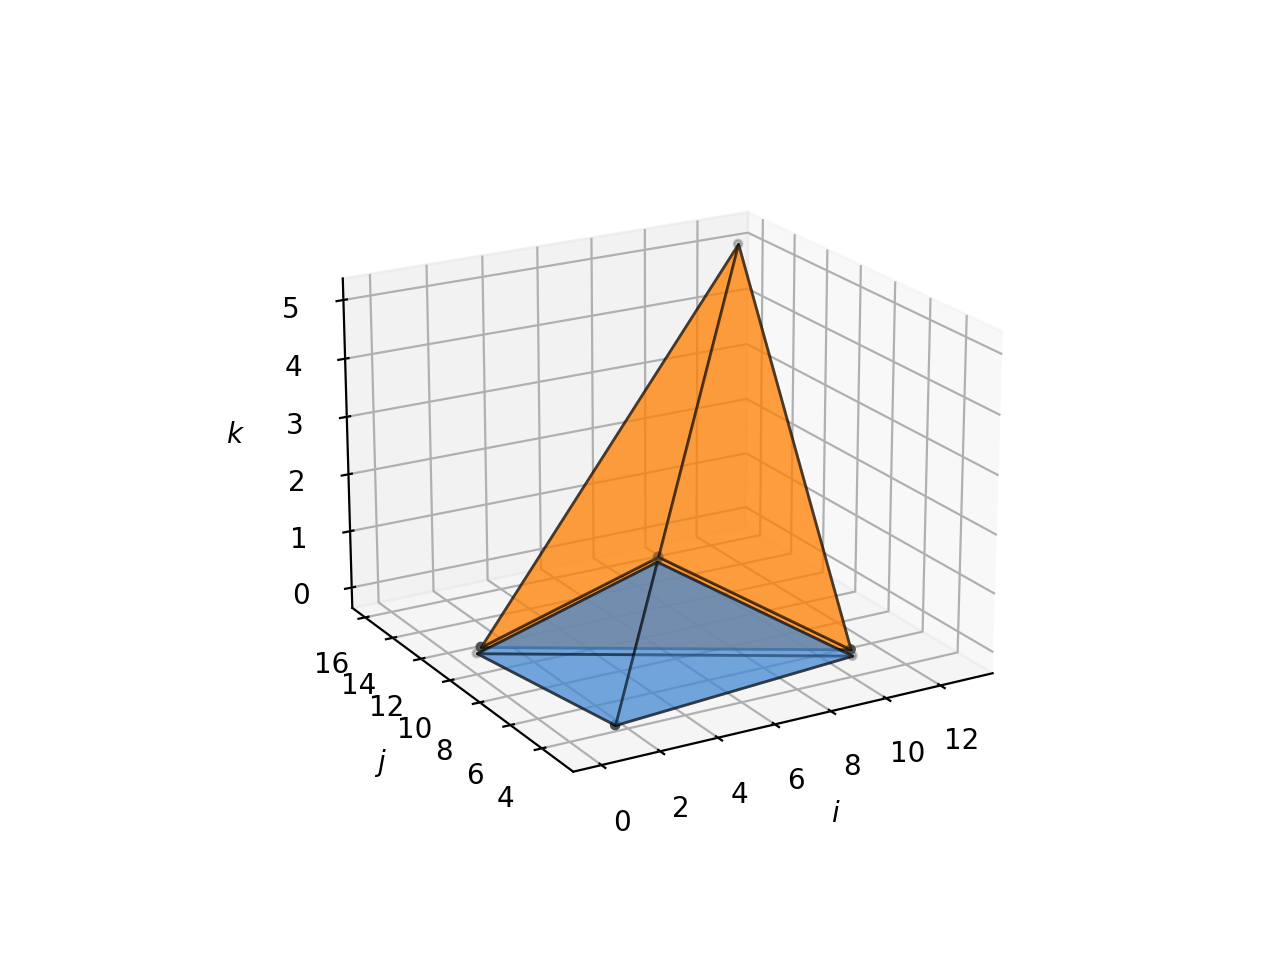

In [8]:
# subcase - top vertex exterior
s = Set('{[1,3,0]; [10,4,0]; [0,10,0]; [13,16,5];}').convex_hull()

# resolution
pieces = split_affine(s, "10j=100-6i")

plot_3d_sets(pieces)

## Scenario 2) 1 boundary face, 3 oblique faces

<IPython.core.display.Javascript object>


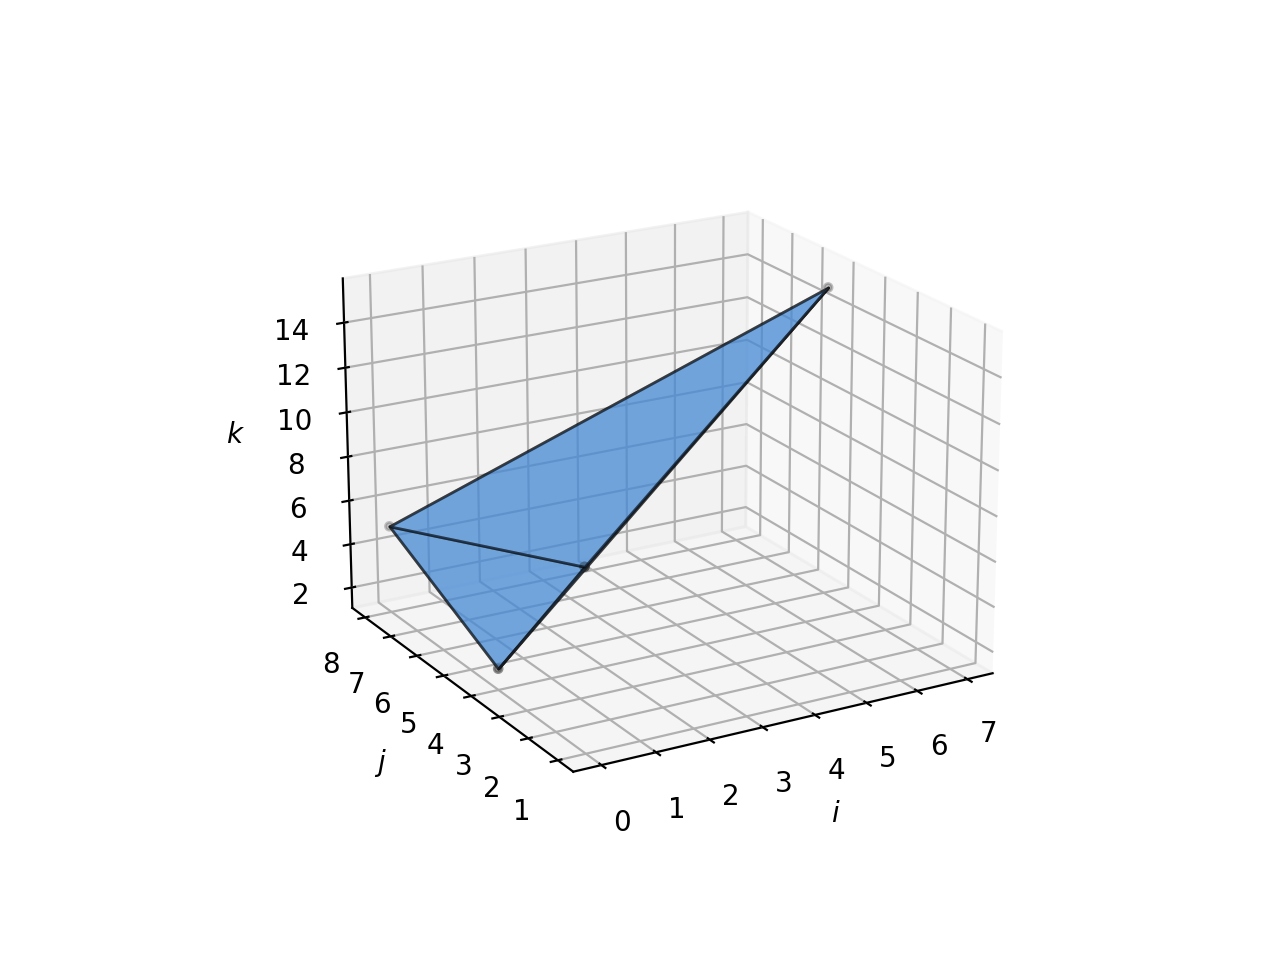

In [9]:
# 0 strong invariant faces
# 1 strong boundary face
# 3 oblique faces
# subcase - top vertex exterior
s = Set('{[0,4,2]; [0,8,5]; [0,1,9]; [7,5,15];}').convex_hull()
plot_3d_set(s)

### resolution - boundary cut through covered edge gives two pieces in scenario 3

<IPython.core.display.Javascript object>


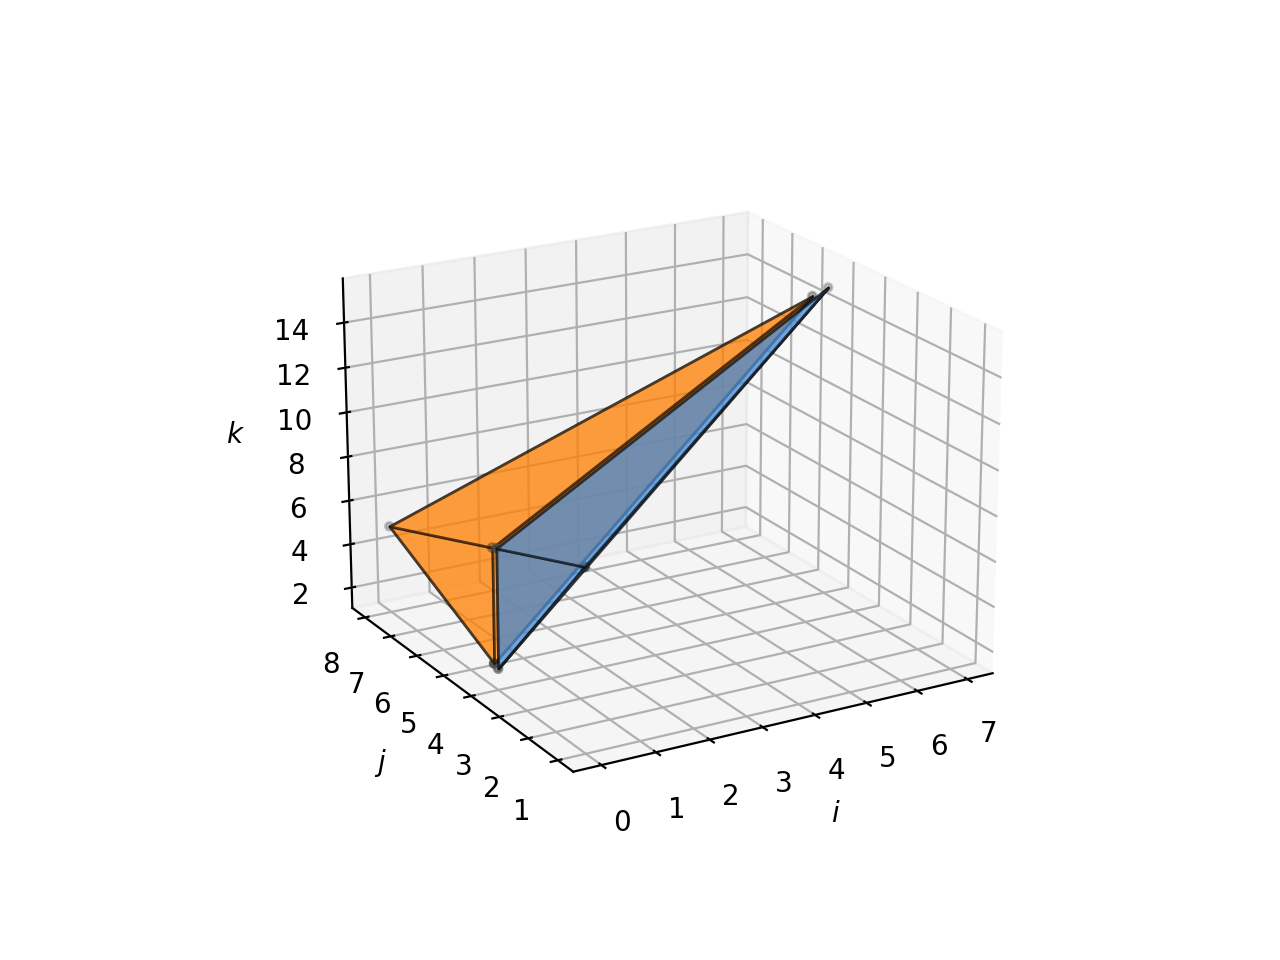

In [10]:
# subcase - top vertex exterior
s = Set('{[0,4,2]; [0,8,5]; [0,1,9]; [7,5,15];}').convex_hull()

# resolution
pieces = split_affine(s, "7j = 28 + i")

plot_3d_sets(pieces)

## Scenario 3) 4 oblique faces

<IPython.core.display.Javascript object>


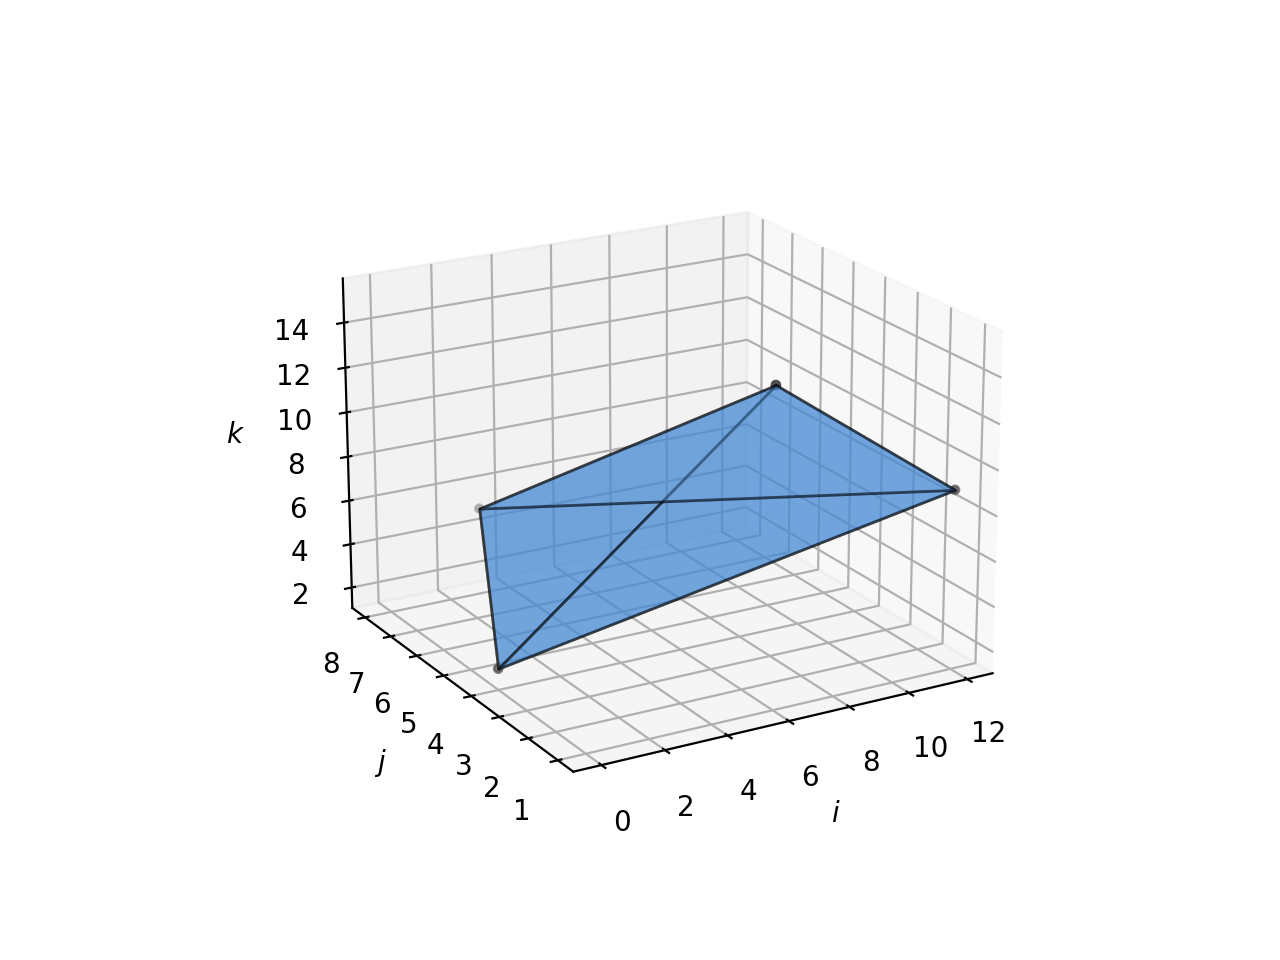

In [11]:
# 4 oblique faces
s = Set('{[0,4,2]; [3,8,5]; [12,1,9]; [6,1,15];}').convex_hull()
plot_3d_set(s)

### resolution - boundary cut through a covered edge gives 2 tetrahedra in case 2

<IPython.core.display.Javascript object>


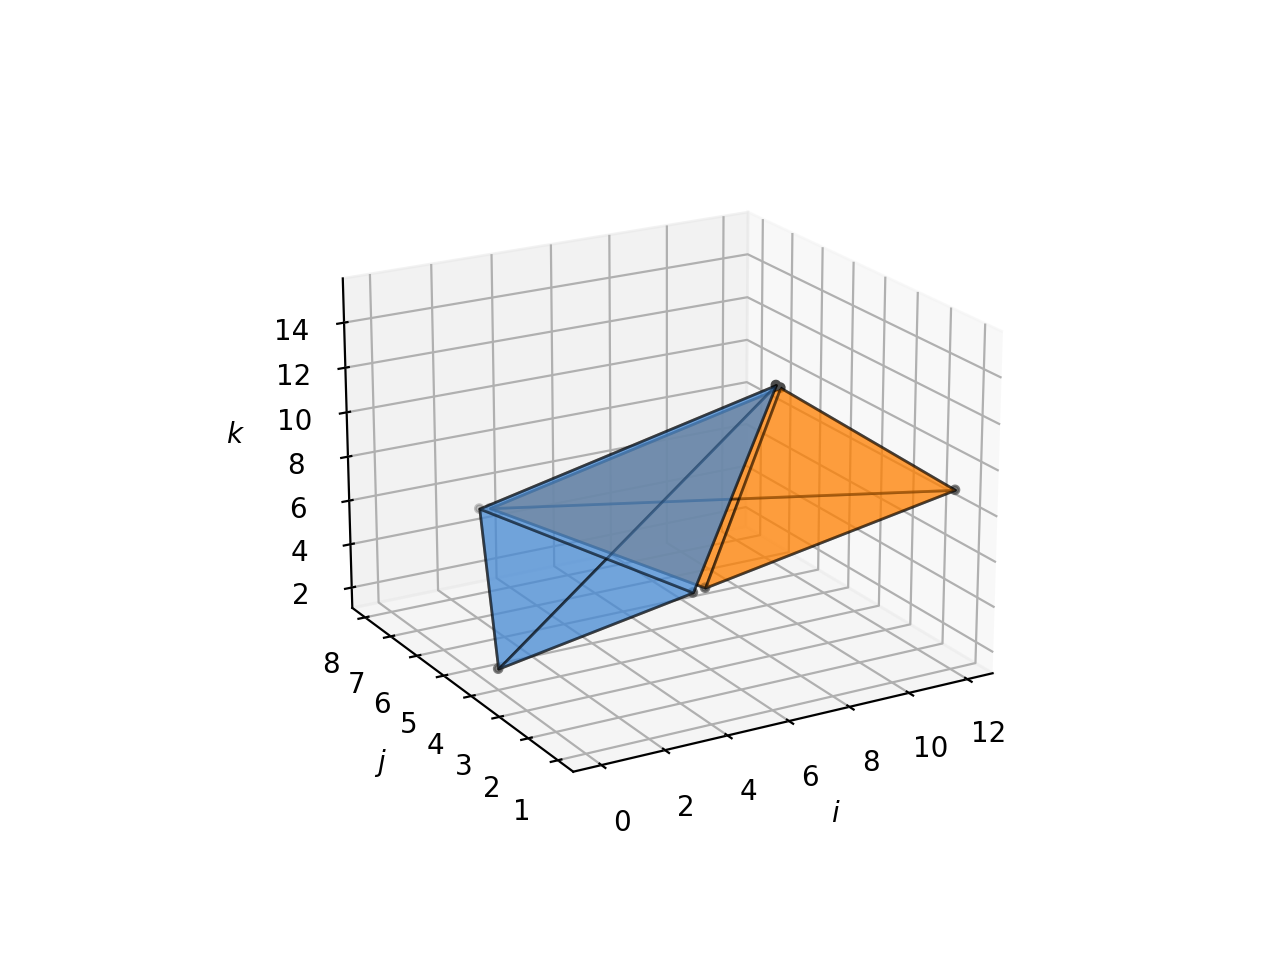

In [12]:
# 4 oblique faces
s = Set('{[0,4,2]; [3,8,5]; [12,1,9]; [6,1,15];}').convex_hull()

S = split_vertices(s, '[3,8,5]', '[6,1,15]', '[6,1,0]')

plot_3d_sets(S)

# 3D reduction with 2D accumulation & 1D reuse

We have the same exact base cases and general cases.
Note that is precisely the complement of the previous case so we do not include visualizations because they would be identical.
However, where we would have made a strong boundary cut previously, here we make a strong invariant cut instead.
And the base case is handled differently.

Now:  
\- reuse upwards along $\hat{k}$  
\- accumulation horizontally in the $ij$-plane (meaning ANY face in the $ij$-plane will ALWAYS be a strong boundary

Any "horizontal" cut (parallel to the $ij$-plane) will expose new strong boundary faces.
And any vertical cut (containing $\hat{k}$ as a basis will expose new strong invariant faces.

Note that there can only every be one strong boundary face, but there may be up to two strong invariant faces.

## base case: 2 or fewer oblique faces

When there are only 2 or fewer oblique faces we do the following to exploit 1 dimension of reuse.

If there is only 1 oblique face, then the space of feasible reuse is non-empty and we do the same thing as before:
1. select any $\rho$ and if it labels the oblique face as a $\ominus$-face then negate it.

If there are 2 oblique faces, then do the following:
1. arbitrary chose an oblique face and intersect it with accumulation space (i.e., the $ij$-plane)
2. decompose projection function fp so the inner reduction is along this intersection
3. pick a $\rho$, if it labels the one remaining obique face as a $\ominus$-face, then negate $\rho$

These are not shown because they are identical to the base cases for the previous case.